In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [33]:
df = pd.read_csv('./Dataset/weatherData.csv', usecols = ['Temperature (C)', 'Humidity'])
df.sample(5)

,Temperature (C),Humidity
44,15.35,81.81
155,14.68,79.85
210,26.95,67.09
124,14.12,87.19
197,40.88,51.69


Text(0, 0.5, 'Humidity')

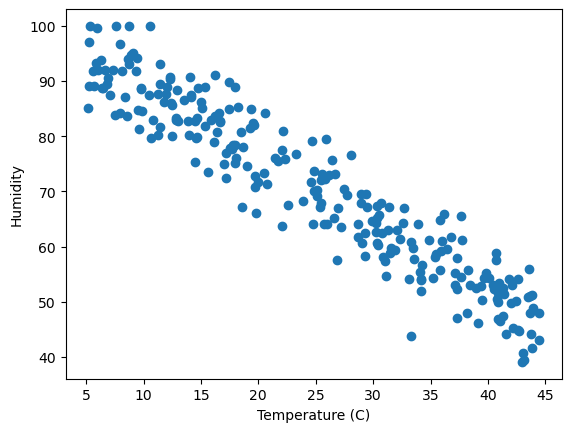

In [35]:
plt.scatter(df['Temperature (C)'], df['Humidity'])
plt.xlabel('Temperature (C)')
plt.ylabel('Humidity')

In [38]:
X = df.drop('Temperature (C)',axis = 1)
y = df['Temperature (C)']

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.8, random_state = 42)

In [56]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [58]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

In [60]:
r2_score(y_test, y_pred)

0.896688449829141

In [74]:
comparison_df = pd.DataFrame({
    'X_test': X_test['Humidity'],
    'Actual (y_test)': y_test,
    'Predicted (y_pred)': y_pred
})
display(comparison_df.head(10))

,X_test,Actual (y_test),Predicted (y_pred)
142,70.07,24.89,25.007367
6,92.08,7.32,8.733807
97,63.72,22.10,29.702374
60,84.17,20.55,14.582233
112,45.23,42.19,43.373348
181,84.69,9.54,14.197760
197,51.69,40.88,38.597010
184,88.87,15.32,11.107189
9,60.78,33.32,31.876126
104,47.49,41.30,41.702369


In [91]:
lr.coef_ #This is the slope of the best fit line

array([-0.7393712])

In [93]:
lr.intercept_ #This is the intercept of the best fit line

76.81510701630589

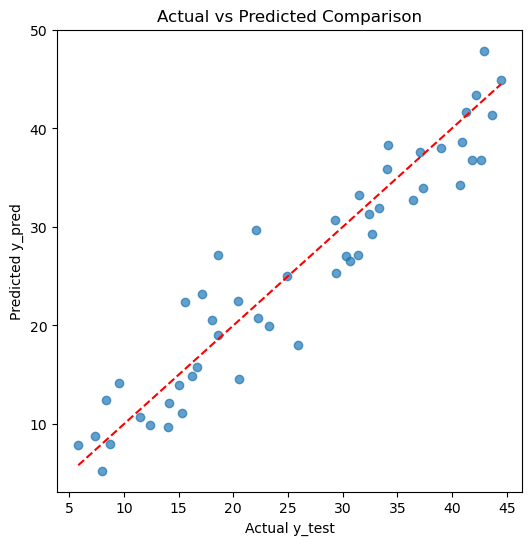

In [95]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual y_test")
plt.ylabel("Predicted y_pred")
plt.title("Actual vs Predicted Comparison")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')  # ideal line
plt.show()